In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Meta Model Dataset/Training_For_Meta_Model.csv")


d:\miniConda\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:38:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


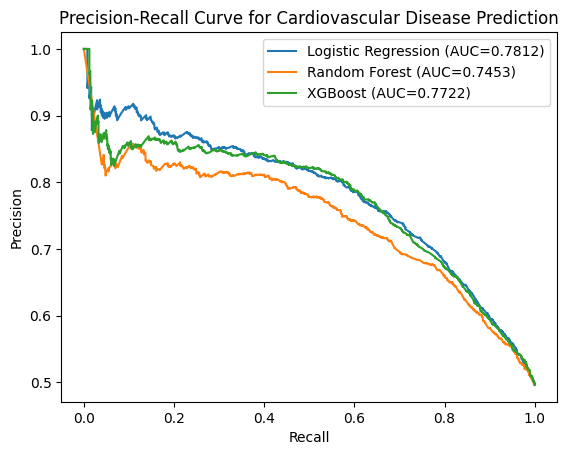

Logistic Regression:
  Precision-Recall AUC = 0.7812
  F1 Score            = 0.7047
  Precision           = 0.7569
  Recall              = 0.6593
  Accuracy            = 0.7261

Random Forest:
  Precision-Recall AUC = 0.7453
  F1 Score            = 0.6806
  Precision           = 0.7221
  Recall              = 0.6435
  Accuracy            = 0.7004

XGBoost:
  Precision-Recall AUC = 0.7722
  F1 Score            = 0.7057
  Precision           = 0.7552
  Recall              = 0.6622
  Accuracy            = 0.7261



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score



# Define target variable (presence of cardiovascular disease)
y = df["Cardiovascular Disease"]

# Select relevant features
features = ["Age", "Systolic Blood Pressure", "Diastolic Blood Pressure", "Cholesterol Level", "Glucose Level", "Smoking Status", "Alcohol Intake", "Physical Activity"]
X = df[features]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

# Evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label=1)
    pr_auc = auc(recall, precision)
    # Default threshold 0.5 for binary prediction
    y_pred = (y_scores >= 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "PR_AUC": pr_auc,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "Accuracy": acc
    }
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Cardiovascular Disease Prediction")
plt.legend()
plt.show()

# Print model performance
for model, metrics in results.items():
    print(f"{model}:")
    print(f"  Precision-Recall AUC = {metrics['PR_AUC']:.4f}")
    print(f"  F1 Score            = {metrics['F1']:.4f}")
    print(f"  Precision           = {metrics['Precision']:.4f}")
    print(f"  Recall              = {metrics['Recall']:.4f}")
    print(f"  Accuracy            = {metrics['Accuracy']:.4f}")
    print()



In [3]:
import tensorflow as tf
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, accuracy_score


def create_nn_model(config, input_dim=2):
    """Create NN model based on configuration"""
    model = tf.keras.Sequential()
    
    # Input layer
    model.add(tf.keras.layers.Dense(
        config['layers'][0], 
        activation=config['activations'][0],
        input_shape=(input_dim,)
    ))
    
    # Add dropout if specified
    if 'dropout' in config and len(config['dropout']) > 0:
        model.add(tf.keras.layers.Dropout(config['dropout'][0]))
    
    # Hidden layers
    for i in range(1, len(config['layers'])):
        model.add(tf.keras.layers.Dense(
            config['layers'][i], 
            activation=config['activations'][i]
        ))
        
        if 'dropout' in config and i < len(config['dropout']):
            model.add(tf.keras.layers.Dropout(config['dropout'][i]))
    
    # Output layer (always sigmoid for binary classification)
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    return model

def evaluate_nn_config(config, X_train, y_train, X_test, y_test, config_name, model_container):
    """Evaluate a single NN configuration"""
    model = create_nn_model(config)
    model_container[config_name] = model
    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    # Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test).flatten()
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # Get final metrics from training
    final_val_loss = min(history.history['val_loss'])
    epochs_trained = len(history.history['loss'])

    Y_actual = y_test
    Y_prob = y_pred_proba

     # --- Compute best F1 score by sweeping thresholds ---
    thresholds = np.linspace(0, 1, 101)  # thresholds from 0.0 to 1.0
    f1_scores = [f1_score(Y_actual, (Y_prob >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    Y_pred_best = (Y_prob >= best_threshold).astype(int)
    # --- ROC curve ---
    fpr, tpr, roc_thresholds = roc_curve(Y_actual, Y_prob)
    

    # --- Precision-Recall curve ---
    precision, recall, pr_thresholds = precision_recall_curve(Y_actual, Y_prob)
    avg_precision = average_precision_score(Y_actual, Y_prob)
    acc = accuracy_score(Y_actual, Y_pred_best)

    results = {
        'config_name': config_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'val_loss': final_val_loss,
        'epochs': epochs_trained,
        'model': model,
        'history': history,
        "F1": best_f1,
        "Best_Threshold": best_threshold,
        "AUC": roc_auc_score(Y_actual, Y_prob),
        "Average_Precision": avg_precision,
        "Accuracy": acc

    }
    
    return results


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import lightgbm as lgb
import os


df = pd.read_csv("Meta Model Dataset/Training_For_Meta_Model.csv")
# Define target variable (presence of cardiovascular disease)
y = df["Cardiovascular Disease"]

# Select relevant features
features = ["Age", "Systolic Blood Pressure", "Diastolic Blood Pressure", "Cholesterol Level", "Glucose Level", "Smoking Status", "Alcohol Intake", "Physical Activity"]
X = df[features]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
lifestyle_columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level', 'id']
health_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake','id']

X = df.drop(['Cardiovascular Disease'], axis=1)
Y = df['Cardiovascular Disease']


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2, 
    random_state=42,
    stratify=Y 
)




health_dataset = X_train.drop(columns=health_columns_to_drop)
lifestyle_dataset = X_train.drop(columns=lifestyle_columns_to_drop)





# Load the trained models
#model_A = lgb.Booster(model_file="saved_models_tausif/lightgbm_model_A.txt")
model_B = lgb.Booster(model_file="Models B/lightgbm_model.txt")
model_A = lgb.Booster(model_file="Saved Models A/lightgbm_model.txt")

predictions_A = model_A.predict(lifestyle_dataset)
predictions_B = model_B.predict(health_dataset)


print(predictions_A)
print(predictions_B)

[0.51450838 0.66875897 0.62748518 ... 0.35488267 0.33029411 0.32365621]
[0.20400517 0.92270298 0.807062   ... 0.22936528 0.58392303 0.22233091]


## Turning off output from health factor model

In [5]:
import numpy as np
# Prepare meta-learner data (probabilities from Model A and B)

# set predictions_B all to 0
zeroed_output_B = np.zeros(len(predictions_B))

meta_X = np.column_stack([predictions_A, zeroed_output_B])

meta_y = Y_train.values

# Split for meta-learner training
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    meta_X, meta_y, test_size=0.2, random_state=42, stratify=meta_y
)

# Test all configurations
configurations = {
    'Simple_4': {'layers': [4], 'activations': ['relu'], 'dropout': [0.1]},
}

results = {}
model_container = {}
for config_name, config in configurations.items():
    print(f"Testing {config_name}...")
    result = evaluate_nn_config(
        config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, config_name, model_container
    )
    results[config_name] = result


Testing Simple_4...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step


In [6]:
import pandas as pd

# Create results comparison
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Configuration': name,
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc'],
        'Val_Loss': result['val_loss'],
        'Epochs': result['epochs'],
        'F1': result['F1'],
        'Best_Threshold': result['Best_Threshold'],
        'AUC': result['AUC'],
        'Average_Precision': result['Average_Precision'],
        'Accuracy': result['Accuracy']
    })

results_df = pd.DataFrame(comparison_data)
results_df = results_df.sort_values('PR-AUC', ascending=False)
print(results_df)


  Configuration   ROC-AUC    PR-AUC  Val_Loss  Epochs        F1  \
0      Simple_4  0.637469  0.632382  0.660425      69  0.668392   

   Best_Threshold       AUC  Average_Precision  Accuracy  
0            0.36  0.637469           0.633188  0.530892  


## Turning off output from lifestyle model

In [15]:
import numpy as np
# Prepare meta-learner data (probabilities from Model A and B)

# set predictions_B all to 0
zeroed_output_A = np.zeros(len(predictions_A))

meta_X = np.column_stack([zeroed_output_A, predictions_B])

meta_y = Y_train.values

# Split for meta-learner training
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    meta_X, meta_y, test_size=0.2, random_state=42, stratify=meta_y
)

# Test all configurations
configurations = {
    'Simple_4': {'layers': [4], 'activations': ['relu'], 'dropout': [0.1]},
}

results = {}
model_container = {}
for config_name, config in configurations.items():
    print(f"Testing {config_name}...")
    result = evaluate_nn_config(
        config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, config_name, model_container
    )
    results[config_name] = result

Testing Simple_4...


d:\miniConda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step


In [16]:
import pandas as pd

# Create results comparison
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Configuration': name,
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc'],
        'Val_Loss': result['val_loss'],
        'Epochs': result['epochs'],
        'F1': result['F1'],
        'Best_Threshold': result['Best_Threshold'],
        'AUC': result['AUC'],
        'Average_Precision': result['Average_Precision'],
        'Accuracy': result['Accuracy']
    })

results_df = pd.DataFrame(comparison_data)
results_df = results_df.sort_values('PR-AUC', ascending=False)
print(results_df)

  Configuration   ROC-AUC    PR-AUC  Val_Loss  Epochs        F1  \
0      Simple_4  0.786254  0.780126  0.559667      66  0.728731   

   Best_Threshold       AUC  Average_Precision  Accuracy  
0            0.42  0.786254           0.775002  0.721281  


## Simple Fusion of prediction values

In [18]:
## take mean of predictions_A and predictions_B
## evaluate performance
mean_predictions = (predictions_A + predictions_B) / 2

meta_y = Y_train.values

# Split for meta-learner training
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    mean_predictions, meta_y, test_size=0.2, random_state=42, stratify=meta_y
)

## evaluate performance
## evaluate performance
mean_roc_auc = roc_auc_score(y_test_meta, X_test_meta)
precision, recall, _ = precision_recall_curve(y_test_meta, X_test_meta)
mean_pr_auc = auc(recall, precision)
print(f"Mean Fusion ROC-AUC: {mean_roc_auc:.4f}")
print(f"Mean Fusion PR-AUC: {mean_pr_auc:.4f}")
print(f"Mean Fusion F1 Score: {f1_score(y_test_meta, X_test_meta > 0.5):.4f}")


Mean Fusion ROC-AUC: 0.7753
Mean Fusion PR-AUC: 0.7569
Mean Fusion F1 Score: 0.7010
